In [69]:
import pandas as pd
from plotnine import *
import os
import json

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

In [70]:
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'

os.makedirs(f'{output_dir}/figures',exist_ok=True)

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [71]:
def graph_plots(summary,variable_name,x_axis_name,y_axis_name,output_path,facet_by_factor_matrix=True,comparator_method_plot=True):
    # variable name is true var name, x-axis name is specific name for x-axis label (like if need latex)
    # if facet_by_factor_matrix is True, facet_wrap by factor matrix else don't
    # baseline methods
    p = (
        ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + labs(y=y_axis_name,x=x_axis_name,color="")
        + theme_bw()
    )
    if facet_by_factor_matrix:
        p = p + facet_wrap('factor_matrix', nrow=1) + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
    else:
        p = p + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top') + ylim(0.5,0.9)
    p.save(f'{output_path}_baseline.jpeg',dpi=300)

    # comparator methods
    if comparator_method_plot:
        p = (
            ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
            + geom_point(size=2)
            + geom_line()
            + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
            + scale_color_manual(values=colors_dict)
            + labs(y=y_axis_name,x=x_axis_name,color="")
            + theme_bw()
            + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
        )
        if facet_by_factor_matrix:
            p = p + facet_wrap('factor_matrix', nrow=1) + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
        else:
            p = p + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top')
        p.save(f'{output_path}_comparator.jpeg',dpi=300)

In [72]:
def simple_graph(summary,variable_name,x_axis_name,y_axis_name,output_path):
    p = (
    ggplot(summary[summary['run_name']=='SCoNE'], aes(variable_name, "mean", color='factor_matrix', group='factor_matrix'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_brewer(type="qual", palette="Paired")
    + labs(y=y_axis_name,x=x_axis_name,color="")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top')
    )
    p.save(f'{output_path}_baseline.pdf',dpi=300)

In [73]:
# lowest loss or highest ll for RGWAS
def get_loss_or_likelihood(row):
    if row.run_name != 'MVBC': 
        with open(f'{row.out_path}_loss_function.json','r') as f:
            loss_function = json.load(f)
        if row.run_name == 'RGWAS':
            loss = - loss_function['ll'][-1]
        else:
            loss = loss_function['total_loss'][-1]
    else:
        loss = 0
    return loss

In [74]:
run_plan = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/models/rho_run_plan.csv')
run_plan['loss'] = run_plan.apply(lambda row: get_loss_or_likelihood(row), axis=1)

In [75]:
from test_reconstruction import get_summary_df, is_sparse
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_results.csv')
df['is_sparse'] = df['run_name'].apply(lambda x: is_sparse(x))

# TUNING: choose optimal sparsity parameters
# choose optimal sparsity based on avg cosine sim for W
tuning_df = df[(df['split']=='tune')&(df['factor_matrix'].isin(['W_C','W_G']))].copy()
tuning_df = tuning_df.groupby(['job_id','run_name','rho','rank','lambda_val'])['sim'].mean().reset_index()
best_df = tuning_df.loc[tuning_df.groupby(['run_name','rho'])['sim'].idxmax()]

# subset df by optimal sparsity params
df = df[(df['is_sparse'] & df['job_id'].isin(best_df['job_id'].unique()))|(~df['is_sparse'])]

# get summary for best params for split train
summary_sim = get_summary_df(df,["run_name", "factor_matrix", "rho","rank"],"sim")
# subset to W_C since rel_error recordings for all factor matrices are duplicates (don't differ by factor matrix)
summary_relerror_G = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "rho","rank"],"rel_error_G") 
summary_relerror_C = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "rho","rank"],"rel_error_C")

assert summary_sim[(summary_sim['run_name']=='MVBC')&(summary_sim['std']!=0)].shape[0] == 0

simple_graph(summary_sim,"rho",x_axis_name=r"$\rho$",y_axis_name="Similarity",output_path=f'{output_dir}/figures/rho')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/rho_baseline.pdf


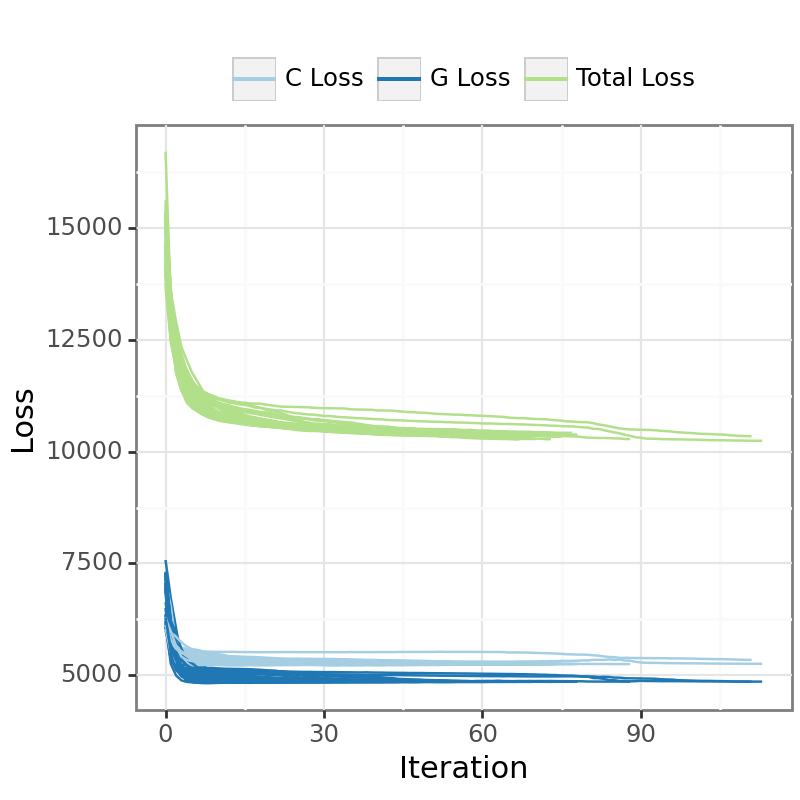

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/loss_example.pdf


In [76]:
job_id = best_df[best_df['rho']==1]['job_id'].values[0]
data = {}
for init in range(50):
    with open(f'{output_dir}/models/rho_train_{job_id}_{init}_loss_function.json','r') as f:
        loss_function = json.load(f)
    data[init] = {k: loss_function[k] for k in ['total_loss','G_loss','C_loss'] if k in loss_function}

df = pd.concat({
    init: pd.DataFrame(losses)
    for init, losses in data.items()
}, names=["init"]).reset_index(level=0)
df["epoch"] = df.groupby("init").cumcount()
df = df.melt( id_vars=["epoch","init"], var_name="loss_type", value_name="loss")
df["group"] = df["init"].astype(str) + "_" + df["loss_type"]
df["label"] = df["loss_type"].str.replace("_", " ").str.title()
p = (
    ggplot(df, aes("epoch", "loss", color='label',group="group"))
    + geom_line()
    + scale_color_brewer(type="qual", palette="Paired")
    + labs(y="Loss",x="Iteration",color="")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top')
)
print(p)
p.save(f'{output_dir}/figures/loss_example.pdf')

# Assess runs over ZU weight

In [77]:
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_results.csv')
df['is_sparse'] = df['run_name'].apply(lambda x: is_sparse(x))

# TUNING: choose optimal sparsity parameters
# choose optimal sparsity based on avg cosine sim for W
tuning_df = df[(df['split']=='tune')&(df['factor_matrix'].isin(['W_C','W_G']))].copy()
tuning_df = tuning_df.groupby(['job_id','run_name','ZU_weight','rank','lambda_val'])['sim'].mean().reset_index()
best_df = tuning_df.loc[tuning_df.groupby(['run_name','ZU_weight'])['sim'].idxmax()]

# subset df by optimal sparsity params
df = df[(df['is_sparse'] & df['job_id'].isin(best_df['job_id'].unique()))|(~df['is_sparse'])]

# get summary for best params for split train
summary_sim = get_summary_df(df,["run_name", "factor_matrix", "ZU_weight","rank"],"sim")
# subset to W_C since rel_error recordings for all factor matrices are duplicates (don't differ by factor matrix)
summary_relerror_G = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "ZU_weight","rank"],"rel_error_G") 
summary_relerror_C = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "ZU_weight","rank"],"rel_error_C")
simple_graph(summary_sim,"ZU_weight",x_axis_name=r"$zu_{weight}$",y_axis_name="Similarity",output_path=f'{output_dir}/figures/zu_weight')


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/zu_weight_baseline.pdf


# Assess runs over sparsity

In [78]:
from test_reconstruction import get_summary_df, is_sparse
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_results.csv')
df['is_sparse'] = df['run_name'].apply(lambda x: is_sparse(x))

# TUNING: choose optimal sparsity parameters
# choose optimal sparsity based on avg cosine sim for W
tuning_df = df[(df['split']=='tune')&(df['factor_matrix'].isin(['W_C','W_G']))].copy()
tuning_df = tuning_df.groupby(['job_id','run_name','sparsity','rank','lambda_val'])['sim'].mean().reset_index()
best_df = tuning_df.loc[tuning_df.groupby(['run_name','sparsity'])['sim'].idxmax()]

# subset df by optimal sparsity params
df = df[(df['is_sparse'] & df['job_id'].isin(best_df['job_id'].unique()))|(~df['is_sparse'])]

# get summary for best params for split train
summary_sim = get_summary_df(df,["run_name", "factor_matrix", "sparsity","rank"],"sim")
# subset to W_C since rel_error recordings for all factor matrices are duplicates (don't differ by factor matrix)
summary_relerror_G = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "sparsity","rank"],"rel_error_G") 
summary_relerror_C = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "sparsity","rank"],"rel_error_C")

assert summary_sim[(summary_sim['run_name']=='MVBC')&(summary_sim['std']!=0)].shape[0] == 0
simple_graph(summary_sim,"sparsity",x_axis_name=r"$sparsity$",y_axis_name="Similarity",output_path=f'{output_dir}/figures/sparsity')


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_baseline.pdf


# Assess runs over nosie

In [79]:
from test_reconstruction import get_summary_df, is_sparse
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_results.csv')
df['is_sparse'] = df['run_name'].apply(lambda x: is_sparse(x))

# TUNING: choose optimal noise parameters
# choose optimal noise based on avg cosine sim for W
tuning_df = df[(df['split']=='tune')&(df['factor_matrix'].isin(['W_C','W_G']))].copy()
tuning_df = tuning_df.groupby(['job_id','run_name','noise','rank','lambda_val'])['sim'].mean().reset_index()
best_df = tuning_df.loc[tuning_df.groupby(['run_name','noise'])['sim'].idxmax()]

# subset df by optimal noise params
df = df[(df['is_sparse'] & df['job_id'].isin(best_df['job_id'].unique()))|(~df['is_sparse'])]

# get summary for best params for split train
summary_sim = get_summary_df(df,["run_name", "factor_matrix", "noise","rank"],"sim")
# subset to W_C since rel_error recordings for all factor matrices are duplicates (don't differ by factor matrix)
summary_relerror_G = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "noise","rank"],"rel_error_G") 
summary_relerror_C = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "noise","rank"],"rel_error_C")

assert summary_sim[(summary_sim['run_name']=='MVBC')&(summary_sim['std']!=0)].shape[0] == 0
simple_graph(summary_sim,"noise",x_axis_name=r"$noise$",y_axis_name="Similarity",output_path=f'{output_dir}/figures/noise')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/noise_baseline.pdf


# Run simple test

In [80]:
import pickle
import numpy as np
from algorithms.SCoNE import compute_loss, l1_norm, l2_norm_squared

def check_decomposition_run(out_path, run_name, lambda_Gloss, lambda_option, G_path, C_path, Z_path, alpha):
    with open(f'{out_path}_factor_matrices.pkl','rb') as f:
        factor_matrices = pickle.load(f)
    if factor_matrices is False:
        return None
    with open(f'{out_path}_loss_function.json','r') as f:
        loss_function = json.load(f)

    
    # make sure recording correct factor matrices
    if run_name in ['RGWAS','MVBC']:
        assert set(factor_matrices.keys())==set(['W'])
    elif run_name in ['SCoNE','SCoNE(Fro)']:
        assert set(factor_matrices.keys())==set(['W','H_G','H_C','U_C','U_G'])
    elif run_name in ['HNMF','HNMF(res)']:
        assert set(factor_matrices.keys())==set(['W','H_G','H_C'])
    elif run_name == 'C-NMF':
        assert set(factor_matrices.keys())==set(['W','H_C'])
    elif run_name == 'C-CoNE':
        assert set(factor_matrices.keys())==set(['W','H_C','U_C'])
    elif run_name == 'G-NMF':
        assert set(factor_matrices.keys())==set(['W','H_G'])
    elif run_name =='G-CoNE':
        assert set(factor_matrices.keys())==set(['W','H_G','U_G'])
    else:
        assert True==False, f"didnt take into account run {run_name}"
    # read in C and G 
    G = pd.read_csv(G_path, index_col=0).to_numpy()
    C = pd.read_csv(C_path, index_col=0).to_numpy()
    Z = pd.read_csv(Z_path, index_col=0).to_numpy()



    if run_name == 'SCoNE':
        Chat = factor_matrices['W']@factor_matrices['H_C'].T + Z@factor_matrices['U_C'].T
        Closs = compute_loss(C,Chat,'kl_div')
        assert np.isclose(Closs, loss_function['C_loss'][-1])
        
        Ghat = factor_matrices['W']@factor_matrices['H_G'].T + Z@factor_matrices['U_G'].T
        Gloss = (lambda_Gloss)*compute_loss(G,Ghat,'kl_div')
        assert np.isclose(Gloss, loss_function['G_loss'][-1])
        
        # since they are post-hoc scaled, need to check that reg values by using recorded norms
        # check L2 reg
        assert np.isclose(alpha*(loss_function['W_norm'][-1]**2), loss_function['l2_regularization'][-1])
        
        # check L1 reg (based on standard inequality between L1 and L2 norm)
        assert lambda_option*(loss_function['H_G_norm'][-1]+loss_function['H_C_norm'][-1]) <= loss_function['l1_regularization'][-1]
        N = factor_matrices['H_G'].shape[0]
        M_G = factor_matrices['H_G'].shape[1]
        M_C = factor_matrices['H_C'].shape[1]
        assert loss_function['l1_regularization'][-1] <= (lambda_option*(np.sqrt(N*M_G)*loss_function['H_G_norm'][-1]+
                                                                             np.sqrt(N*M_C)*loss_function['H_C_norm'][-1]))


    
    else: assert True == False, f"not accounting for {run_name}, look to AoU to grab proper test code"

In [81]:
for variable in ['noise','sparsity','ZU_weight','rho']:
    for split in ['train','tune']:
        run_plan = pd.read_csv(f'{output_dir}/models/{variable}_run_plan.csv')
        run_plan = run_plan[run_plan['split']==split].copy()
        run_record = pd.read_csv(f'{output_dir}/models/{variable}_run_record_{split}.csv')
        run_plan = run_plan.merge(run_record[['job_id','alpha']]).copy()
        for i, row in run_plan.iterrows():
            G_path = f'{output_dir}/tmp/G_{variable}_{row.variable}.csv'
            C_path = f'{output_dir}/tmp/C_{variable}_{row.variable}.csv'
            Z_path = f'{output_dir}/tmp/Z_{variable}_{row.variable}.csv'
            check_decomposition_run(row.out_path,row.run_name,lambda_Gloss=1,lambda_option=row.lambda_option,
                            G_path=G_path, C_path=C_path, Z_path=Z_path, alpha=row.alpha)
